In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv")
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,389,113095465,48,24,9668,10012,403,0,201.416667,203.548293,...,32,203985.500,5.758373e+05,1629110,379,13800000.0,4.277541e+06,16500000,6737603,BENIGN
1,389,113473706,68,40,11364,12718,403,0,167.117647,171.919413,...,32,178326.875,5.034269e+05,1424245,325,13800000.0,4.229413e+06,16500000,6945512,BENIGN
2,0,119945515,150,0,0,0,0,0,0.000000,0.000000,...,0,6909777.333,1.170000e+07,20400000,6,24400000.0,2.430000e+07,60100000,5702188,BENIGN
3,443,60261928,9,7,2330,4221,1093,0,258.888889,409.702161,...,20,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,53,269,2,2,102,322,51,51,51.000000,0.000000,...,32,0.000,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN


<h1 align="left"><font color='#FFB703'>Data Cleaning.</font></h1>

# <h2 align="left"><font color='#FFB703'>Check for Columns with Null values.</font></h2>

In [ ]:
df.isnull().sum().any()

np.True_

In [ ]:
df.isnull().sum()[df.isnull().sum()>0]

,0
Flow Bytes/s,20


In [ ]:
nullNum = df['Flow Bytes/s'].isnull().sum()
print(f"Number of null Values in Flow Bytes: {nullNum} ")

Number of null Values in Flow Bytes: 20 


In [ ]:
nullObj = df.columns[df.isnull().any()==True]
print(f"Obejcts that contains null values in dataset: {nullObj} ")

Obejcts that contains null values in dataset: Index(['Flow Bytes/s'], dtype='object') 


In [ ]:
df.shape

(170366, 79)

In [ ]:
df = df.dropna()

In [ ]:
df.shape

(170346, 79)

# <h2 align="left"><font color='#FFB703'>Standardise column names</font></h2>

In [ ]:
df.columns = df.columns.str.strip()
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

# <h2 align="left"><font color='#FFB703'>Check for Columns with duplicates.</font></h2>

In [ ]:
df.duplicated().sum()

np.int64(6065)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.shape

(164281, 79)

In [ ]:
df.duplicated().any()

np.False_

# <h2 align="left"><font color='#FFB703'>Check for Columns without Variance.</font></h2>

In [ ]:
df.columns[df.nunique()==1]

Index(['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'],
      dtype='object')

In [ ]:
df.shape

(164281, 79)

In [ ]:
df = df.drop(['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count',
       'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'], axis=1)

In [ ]:
df.shape

(164281, 69)

# <h2 align="left"><font color='#FFB703'>Check for Columns with Inf values.</font></h2>

In [ ]:
numeric_df = df.select_dtypes(include=[np.number]) #Select numeric columns only

In [ ]:
np.isinf(numeric_df).sum().sum() #Check for infinite values

np.int64(204)

In [ ]:
np.isinf(numeric_df).sum()[np.isinf(numeric_df).sum()>0] #See which columns contain infinite values

,0
Flow Bytes/s,102
Flow Packets/s,102


In [ ]:
df[np.isinf(df["Flow Bytes/s"]) | np.isinf(df["Flow Packets/s"])][["Flow Bytes/s", "Flow Packets/s"]]


,Flow Bytes/s,Flow Packets/s
135,inf,inf
359,inf,inf
495,inf,inf
765,inf,inf
2742,inf,inf
...,...,...
162780,inf,inf
164734,inf,inf
165266,inf,inf
165268,inf,inf


In [ ]:
df = df.replace([np.inf, -np.inf], np.nan) #replace the inf & -inf values with null values

In [ ]:
df[df["Flow Bytes/s"].isna() | df["Flow Packets/s"].isna()][["Flow Bytes/s", "Flow Packets/s"]]

,Flow Bytes/s,Flow Packets/s
135,NaN,NaN
359,NaN,NaN
495,NaN,NaN
765,NaN,NaN
2742,NaN,NaN
...,...,...
162780,NaN,NaN
164734,NaN,NaN
165266,NaN,NaN
165268,NaN,NaN


In [ ]:
df = df.dropna() #drop the null values

In [ ]:
numeric_df = df.select_dtypes(include=[np.number]) #Recompute numeric_df after replacement

In [ ]:
np.isinf(numeric_df).sum().sum() #Check for infinite values

np.int64(0)

# <h2 align="left"><font color='#FFB703'>Check for Invalid Flow Duration values.</font></h2>

In [ ]:
(df["Flow Duration"] < 0).sum() #check if there are invalid rows,as time cannot be negative in real network traffic.

np.int64(11)

In [ ]:
df = df.drop(df[df["Flow Duration"] < 0].index) #Drop them

In [ ]:
(df["Flow Duration"] < 0).sum()

np.int64(0)

# <h2 align="left"><font color='#FFB703'>Renaming Label Rows</font></h2>

In [ ]:
df["Label"].value_counts()

,count
Label,
BENIGN,162025
Web Attack � Brute Force,1470
Web Attack � XSS,652
Web Attack � Sql Injection,21


In [ ]:
df["Label"] = df["Label"].str.strip().replace("Web Attack � Brute Force", "Web Attack Brute Force")
df["Label"] = df["Label"].str.strip().replace("Web Attack � XSS", "Web Attack XSS")
df["Label"] = df["Label"].str.strip().replace("Web Attack � Sql Injection", "Web Attack SQL Injection")

In [ ]:
df["Label"].value_counts()

,count
Label,
BENIGN,162025
Web Attack Brute Force,1470
Web Attack XSS,652
Web Attack SQL Injection,21


# <h2 align="left"><font color='#FFB703'>Umsampling against Class Imbalance</font></h2>

In [ ]:
benign_total = len(df[df['Label'] == "BENIGN"]) #number of BENIGN
benign_total

162025

In [ ]:
attack_total = len(df[df['Label'] != "BENIGN"]) #number of attacks
attack_total

2143

In [ ]:
max_benign = attack_total / 30 * 70 #maximum number of benign samples to keep

In [ ]:
benign_probability = (max_benign / benign_total)
print(max_benign, benign_probability) #each benign row has roughly a 3.08% chance of being included.

5000.333333333334 0.03086149256801934


In [ ]:
#the dataset is unbalanced, total records = 164168, BENIGN = 162025, attacks are 2143

In [ ]:
#make attacks as 30% in porportion to the dataset, 70% benign
#30% = 2143, benign 70% = 2143/30 *70 = 5000.333~ 5001 records

In [ ]:
#Copy all records with the attacks to new dataset
#and total number of benign should not exceed 5001 records

# <h2 align="left"><font color='#FFB703'>Creating a Balanced Dataset</font></h2>

---





In [ ]:

import random
random.seed(41)
indexes = []
benign_included = 0
for i ,row in df.iterrows():
  if (row['Label']!='BENIGN'): #copy all attacks
    indexes.append(i)
  else:
    #Benign rows are only if
    if random.random()>=benign_probability:#A random number passes the probability filter:
      continue #96.92% of benign rows are skipped, ~3.08% are kep
    if benign_included > max_benign: #If the maximum number of benign samples has already been reached, any remaining benign rows are skipped
      continue
    benign_included += 1
    indexes.append(i)
df_balanced = df.loc[indexes] #Builds a new dataframe that contains all benign and attack records

In [ ]:
df_balanced['Label'].value_counts()

,count
Label,
BENIGN,5001
Web Attack Brute Force,1470
Web Attack XSS,652
Web Attack SQL Injection,21


In [ ]:
df_balanced.head(3)

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
48,53,201,2,2,88,188,44,44,44.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
117,53,178,2,2,48,48,24,24,24.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
159,53,201,2,2,64,96,32,32,32.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [ ]:
df_balanced.to_csv("web_attacks_balanced.csv", index=False)
#write bf_balanced dataframe into web_attacks_balanced.csv file

In [ ]:
df = pd.read_csv("web_attacks_balanced.csv")
df['Label'].value_counts()

,count
Label,
BENIGN,5001
Web Attack Brute Force,1470
Web Attack XSS,652
Web Attack SQL Injection,21


In [ ]:
df.head() #Double check the new web attacks balanced csv file

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,53,201,2,2,88,188,44,44,44.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,53,178,2,2,48,48,24,24,24.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,53,201,2,2,64,96,32,32,32.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,53,235,2,2,64,158,32,32,32.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,88,508,2,2,348,358,174,174,174.0,0.0,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


<h1 align="left"><font color='#FFB703'>Exploratory Data Analysis (EDA)</font></h1>

---



<h3>Univariate Non-graphical EDA</h3>






In [ ]:
df.info()
# Displays dataset structure, including number of rows, columns, data types, and missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7144 entries, 0 to 7143
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             7144 non-null   int64  
 1   Flow Duration                7144 non-null   int64  
 2   Total Fwd Packets            7144 non-null   int64  
 3   Total Backward Packets       7144 non-null   int64  
 4   Total Length of Fwd Packets  7144 non-null   int64  
 5   Total Length of Bwd Packets  7144 non-null   int64  
 6   Fwd Packet Length Max        7144 non-null   int64  
 7   Fwd Packet Length Min        7144 non-null   int64  
 8   Fwd Packet Length Mean       7144 non-null   float64
 9   Fwd Packet Length Std        7144 non-null   float64
 10  Bwd Packet Length Max        7144 non-null   int64  
 11  Bwd Packet Length Min        7144 non-null   int64  
 12  Bwd Packet Length Mean       7144 non-null   float64
 13  Bwd Packet Length 

In [ ]:
df.describe()
# Generates summary statistics (count, mean, std, min, quartiles, max) for numeric features

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,7144.000000,7.144000e+03,7144.000000,7144.000000,7144.000000,7.144000e+03,7144.000000,7144.000000,7144.000000,7144.000000,...,7144.000000,7144.000000,7.144000e+03,7.144000e+03,7.144000e+03,7.144000e+03,7.144000e+03,7.144000e+03,7.144000e+03,7.144000e+03
mean,5796.692749,1.142794e+07,9.405655,8.547872,940.749300,9.419331e+03,143.647536,16.430571,39.873262,42.039196,...,5.421333,27.569989,5.393598e+04,3.500425e+04,1.251910e+05,3.689880e+04,2.788023e+06,9.392256e+04,2.854888e+06,2.679366e+06
std,16017.374774,2.825314e+07,90.063010,132.870523,5690.975975,2.363022e+05,473.246419,33.421631,91.228180,133.193913,...,85.991876,6.051982,4.554680e+05,2.621553e+05,7.742544e+05,4.253030e+05,1.157056e+07,1.394466e+06,1.176883e+07,1.145150e+07
min,0.000000,1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,5.100000e+02,2.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,1.593795e+05,3.000000,1.000000,48.000000,7.100000e+01,33.000000,0.000000,30.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,5.609156e+06,3.000000,2.000000,102.000000,2.540000e+02,51.000000,36.000000,48.000000,1.829368,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,63248.000000,1.199997e+08,4361.000000,6677.000000,152339.000000,1.160000e+07,23360.000000,1336.000000,3808.475000,4254.899077,...,4289.000000,44.000000,1.690000e+07,9.147530e+06,2.090000e+07,1.690000e+07,1.200000e+08,3.740000e+07,1.200000e+08,1.200000e+08


In [ ]:
df.skew(numeric_only=True)
# Numeric only means to only calculate skewness using numeric columns and to ignore non numeric ones.

,0
Destination Port,2.557607
Flow Duration,3.003715
Total Fwd Packets,42.985432
Total Backward Packets,46.888188
Total Length of Fwd Packets,9.931641
...,...
Active Min,23.010660
Idle Mean,5.989155
Idle Std,22.435172
Idle Max,5.855451


Sorting values from significant columns to rank them and see extreme values/anomalies:

sort_values rearranges the rows of the dataset so that you can easily see which entires have the highest or lowest values for a chosen column. A quick skew check for the column is also included.

In [ ]:
df.sort_values(by='Total Fwd Packets', ascending=False).head()
## This shows aggresive traffic, and we can see which flows sent the most packets, which can be an indicator of brute force or DDoS behavior.

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
6400,443,117876717,4361,6677,85275,11400000,1221,0,19.554001,128.091511,...,20,0.0,0.000,0,0,0.0,0.000000,0,0,BENIGN
6218,443,119502231,4274,6509,90894,11600000,1221,0,21.266729,135.731936,...,20,0.0,0.000,0,0,0.0,0.000000,0,0,BENIGN
6101,443,118791710,3993,5981,84012,11200000,1221,0,21.039820,135.146533,...,20,0.0,0.000,0,0,0.0,0.000000,0,0,BENIGN
5710,443,47948991,650,856,12622,1683792,517,0,19.418462,65.624207,...,20,5306835.0,9147530.159,15900000,25497,10000000.0,249.980666,10000000,10000000,BENIGN
440,80,1805120,348,502,2413,1078269,1516,0,6.933908,84.600255,...,32,0.0,0.000,0,0,0.0,0.000000,0,0,BENIGN


In [ ]:
df["Total Fwd Packets"].skew()

np.float64(42.98543182091698)

In [ ]:
df["Total Fwd Packets"].median()

3.0

In [ ]:
df.sort_values(by='Flow Duration', ascending=False).head()
# This shows the longest sessions, where we can see which sessions are abnormally long, which might indicate possible slow attacks or hanging sessions.

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
3722,443,119999653,4,2,32,64,32,0,8.000000,16.000000,...,32,3.400000e+01,4.242641e+00,37,31,6.000000e+07,74.246212,60000000,60000000,BENIGN
2540,443,119999536,17,16,1363,2412,637,6,80.176471,209.392644,...,20,9.635175e+04,1.878222e+05,503676,15117,9.902275e+06,265124.388800,10000000,9303979,BENIGN
5009,80,119982360,17,16,2563,717,909,6,150.764706,323.344346,...,20,9.278445e+05,1.948458e+06,4894504,46473,9.979643e+06,45456.932160,10000000,9846719,BENIGN
5101,80,119954574,17,15,2563,711,909,6,150.764706,323.344346,...,20,1.016973e+06,2.038627e+06,4900872,46516,9.980440e+06,42623.698210,10000000,9856204,BENIGN
497,443,119947839,17,12,2830,484,944,0,166.470588,338.189687,...,32,4.743769e+05,1.420787e+06,4757962,76,1.000000e+07,60216.027670,10000000,9822754,BENIGN


In [ ]:
df["Flow Duration"].skew()

np.float64(3.0037154340325833)

In [ ]:
df["Flow Duration"].median() #Median check for comparison

159379.5

In [ ]:
df.sort_values(by='Flow Bytes/s', ascending=False)[
    [
        'Flow Bytes/s',
        'Total Fwd Packets',
        'Flow Duration',
        'Flow IAT Std',
        'SYN Flag Count',
        'Label'
    ]
].head()

#find sudden spikes in traffic that might indicate automation or flooding activity.
#Flow bytes = number of bytes transferred per second
#As pandas concatenates the flow bytes column by default, we will need to purposefully show it alongside some other relevant columns.

,Flow Bytes/s,Total Fwd Packets,Flow Duration,Flow IAT Std,SYN Flag Count,Label
6885,617000000.0,2,1,0.0,1,BENIGN
660,617000000.0,2,1,0.0,1,BENIGN
4278,611000000.0,2,1,0.0,1,BENIGN
5891,309000000.0,2,2,0.0,1,BENIGN
5139,247000000.0,2,1,0.0,1,BENIGN


In [ ]:
df["Flow Bytes/s"].skew()

np.float64(38.06369527645146)

In [ ]:
df["Flow Bytes/s"].median()

650.72268835

In [ ]:
df.sort_values(by='Flow IAT Std', ascending=True)[ #True is used here to show the extreme low variabilites first.
    [
        'Flow IAT Std',
        'Flow Duration',
        'Total Fwd Packets',
        'Flow Bytes/s',
        'SYN Flag Count',
        'Label'
    ]
]

# Fwd IAT Total is the timing variabilities for forward packets.
# Low calues mean that packets are sent at perfect intervals, which potentially indicates automated attack tools.
#As pandas concatenates the flow IAT std column by default, we will need to purposefully show it alongside some other relevant columns.

,Flow IAT Std,Flow Duration,Total Fwd Packets,Flow Bytes/s,SYN Flag Count,Label
1535,0.0,60693,1,3196.414743,0,BENIGN
4829,0.0,1208,1,9933.774834,0,BENIGN
4828,0.0,49,2,244897.959200,0,BENIGN
4777,0.0,68,1,0.000000,0,BENIGN
4776,0.0,151,1,0.000000,0,BENIGN
...,...,...,...,...,...,...
2053,68400000.0,118533322,2,3.467379,0,BENIGN
6026,68600000.0,118978613,2,2.958515,0,BENIGN
3556,68700000.0,119169334,2,2.332815,0,BENIGN
594,68900000.0,119373271,2,3.484867,0,BENIGN


In [ ]:
df["Flow IAT Std"].skew()

np.float64(7.421183102391652)

In [ ]:
df["Flow IAT Std"].median()

35776.52365

In [ ]:
df.sort_values(by='Total Backward Packets', ascending=False)[
    [
        'Total Backward Packets',
        'Flow Duration',
        'Flow Bytes/s',
        'Total Fwd Packets',
        'Label'
    ]
].head()


,Total Backward Packets,Flow Duration,Flow Bytes/s,Total Fwd Packets,Label
6400,6677,117876717,97024.24101,4361,BENIGN
6218,6509,119502231,97551.77709,4274,BENIGN
6101,5981,118791710,94612.17454,3993,BENIGN
5710,856,47948991,35379.55574,650,BENIGN
440,502,1805120,598675.98830,348,BENIGN


In [ ]:
df["Total Backward Packets"].skew()

np.float64(46.88818790550977)

In [ ]:
df["Total Backward Packets"].median()

1.0

---

<h3>Univariate Graphical EDA</h3>

---



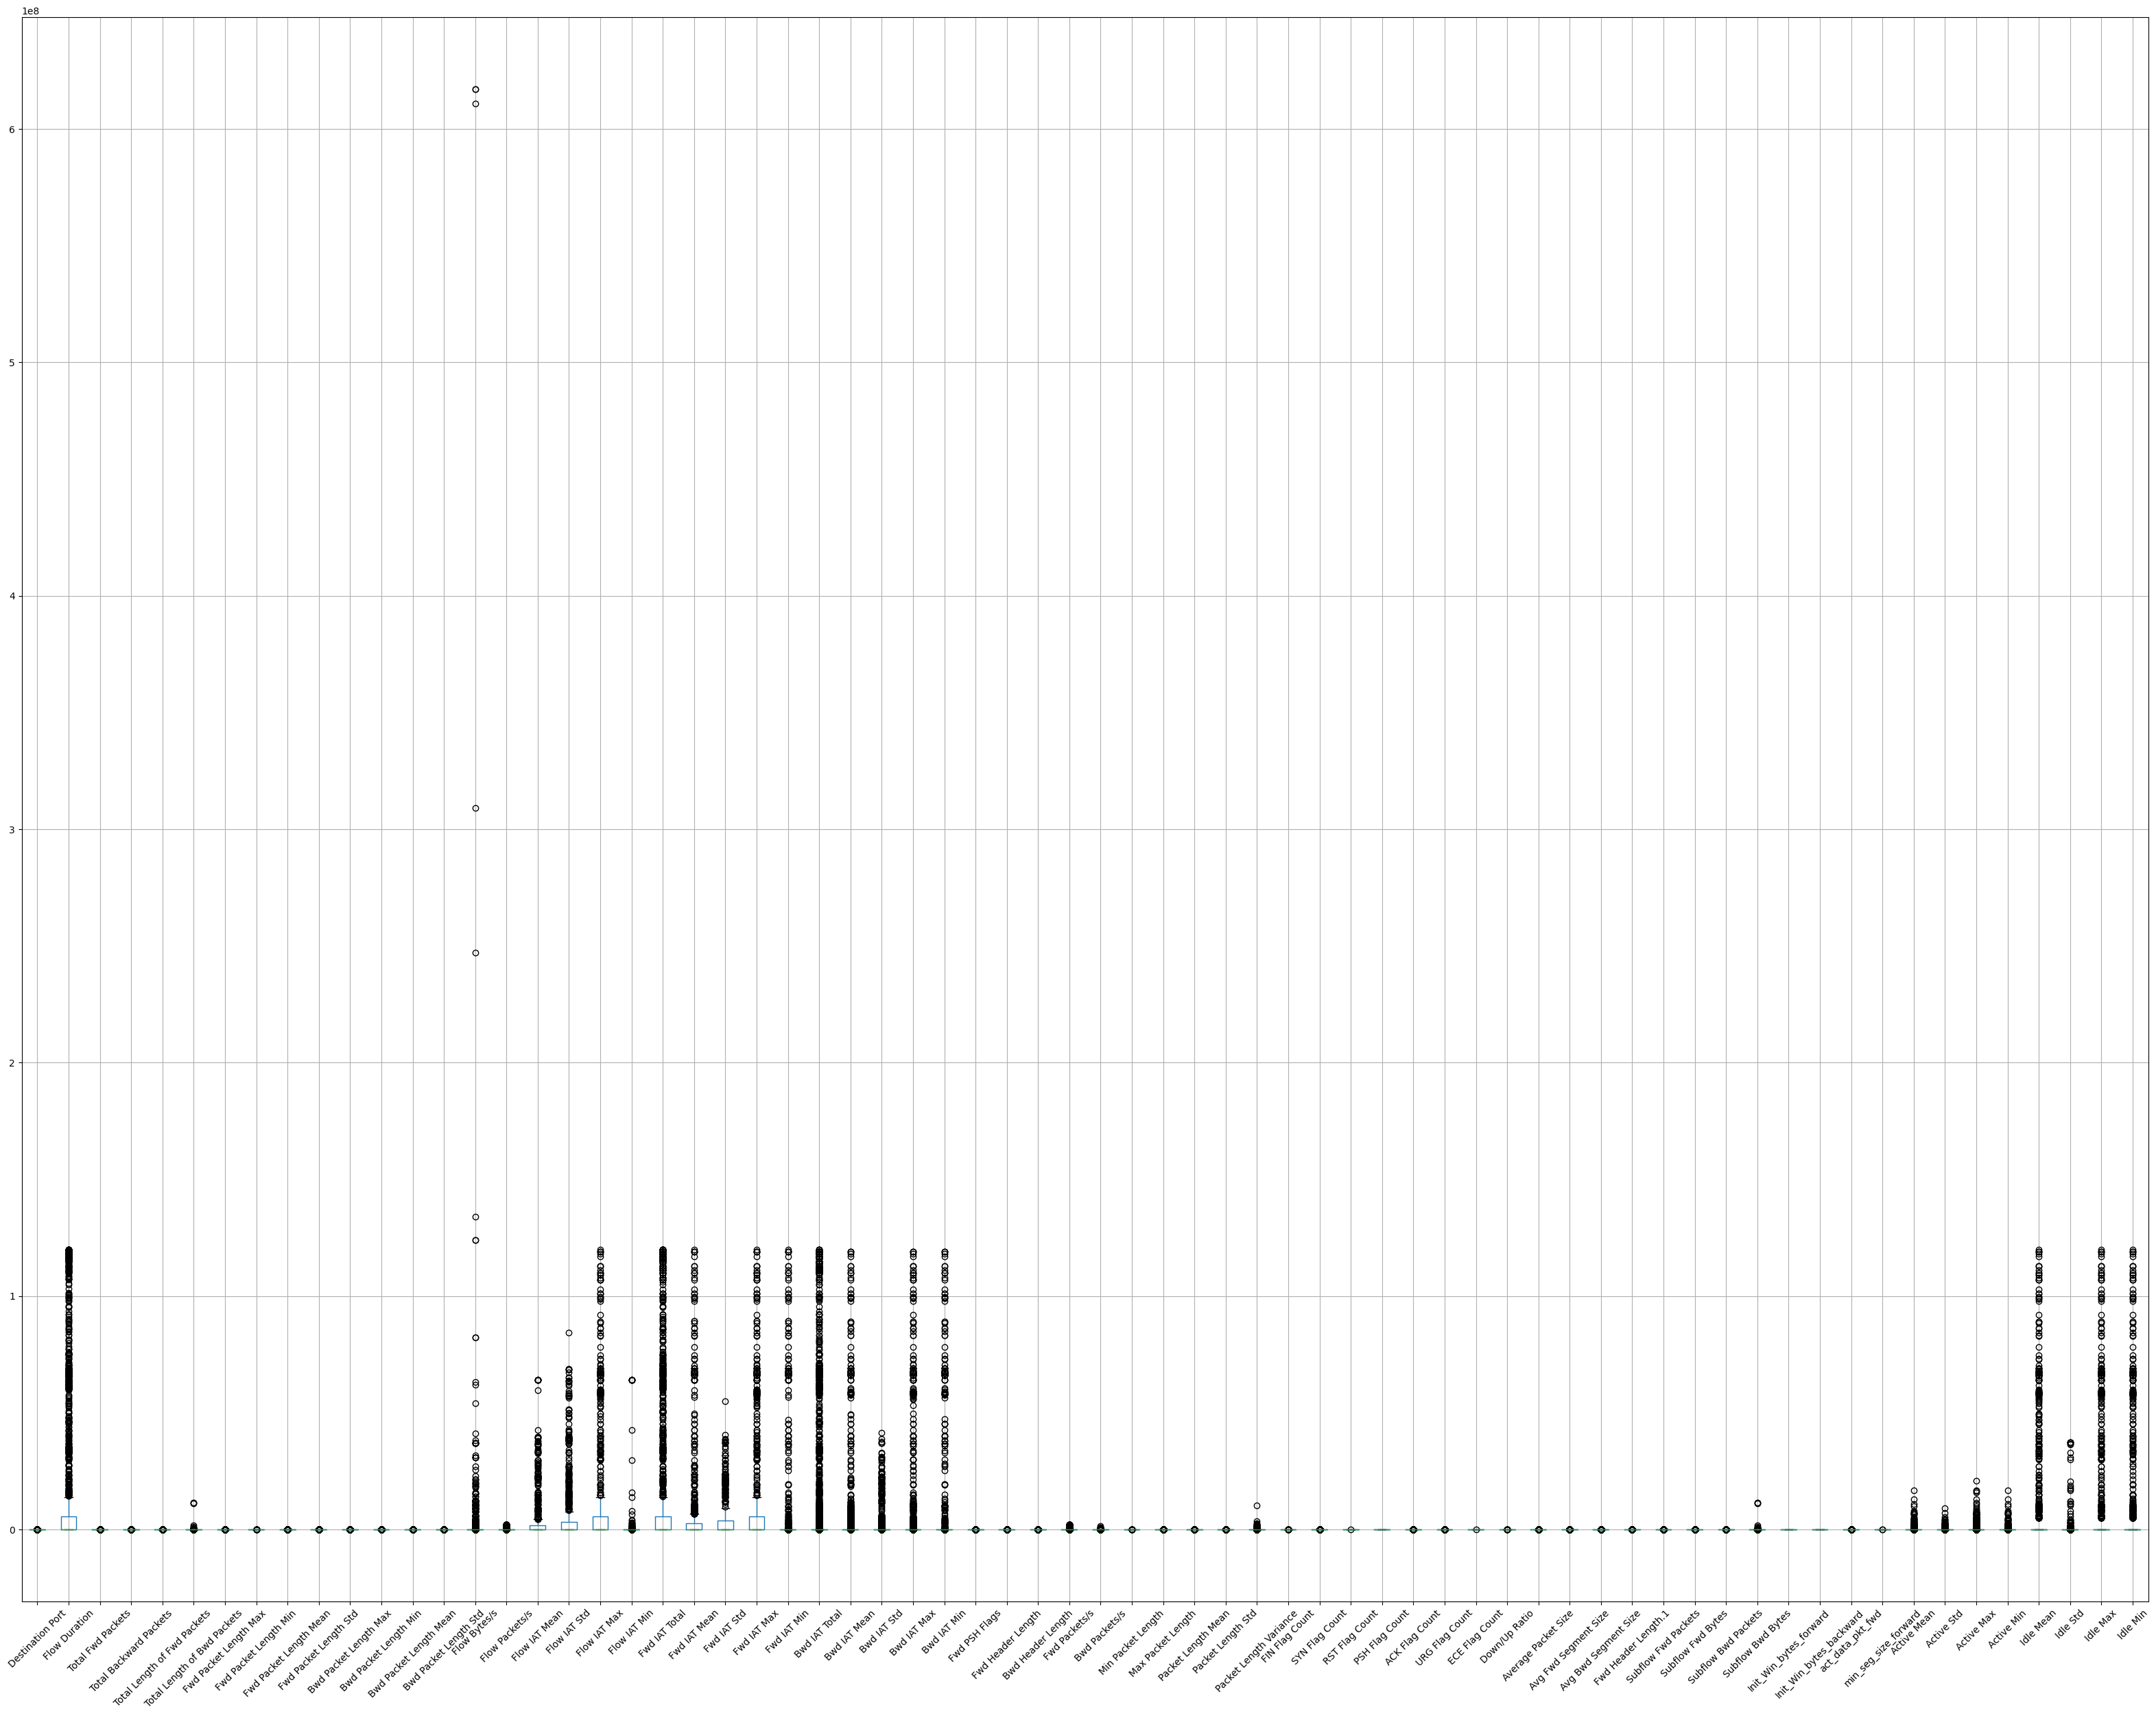

In [ ]:


df.boxplot(figsize=(40,30))
plt.xticks(rotation=45) #To rotate the x axis labels for better visibility
plt.show()

#To examine the spread, median, extreme values of each feature, and especially to find outliers.


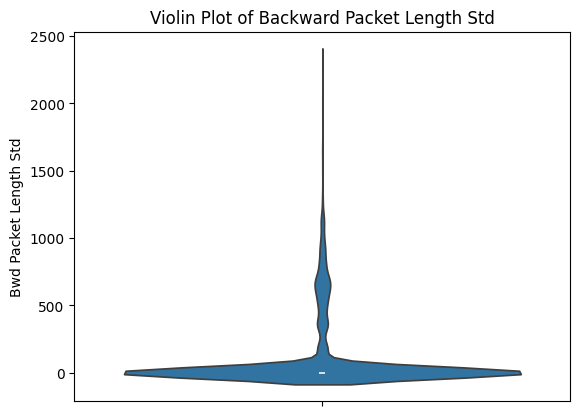

In [ ]:
sns.violinplot(y=df['Bwd Packet Length Std'])
plt.title('Violin Plot of Backward Packet Length Std')
plt.show()
#for further inspection into features with extreme values above

In [ ]:
# sns.violinplot(y=df['Bwd Packet Length Mean'])
# plt.title('Violin Plot of Backward Packet Length Mean')
# plt.show()
##backup code


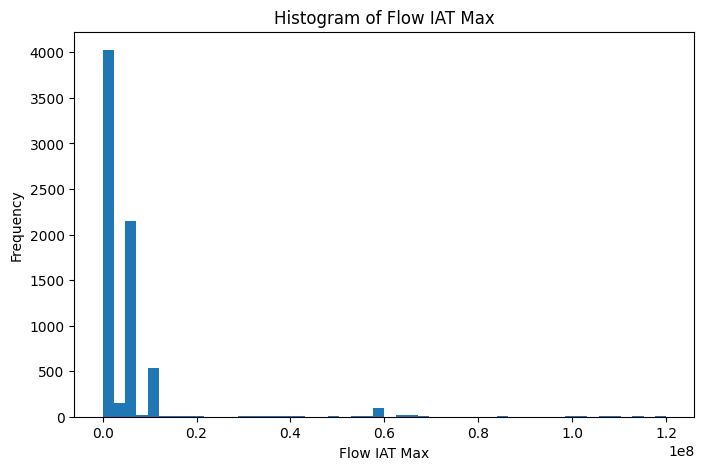

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df['Flow IAT Max'], bins=50)
plt.title('Histogram of Flow IAT Max')
plt.xlabel('Flow IAT Max')
plt.ylabel('Frequency')
plt.show()


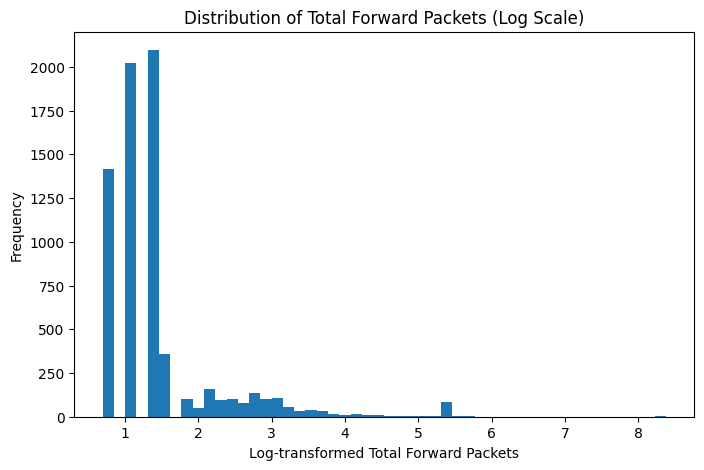

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Total Fwd Packets']), bins=50)
plt.xlabel('Log-transformed Total Forward Packets')
plt.ylabel('Frequency')
plt.title('Distribution of Total Forward Packets (Log Scale)')
plt.show()


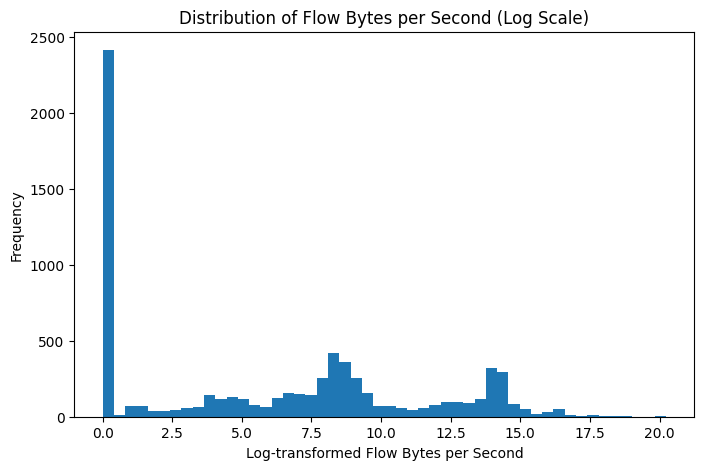

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Flow Bytes/s']), bins=50)
plt.xlabel('Log-transformed Flow Bytes per Second')
plt.ylabel('Frequency')
plt.title('Distribution of Flow Bytes per Second (Log Scale)')
plt.show()




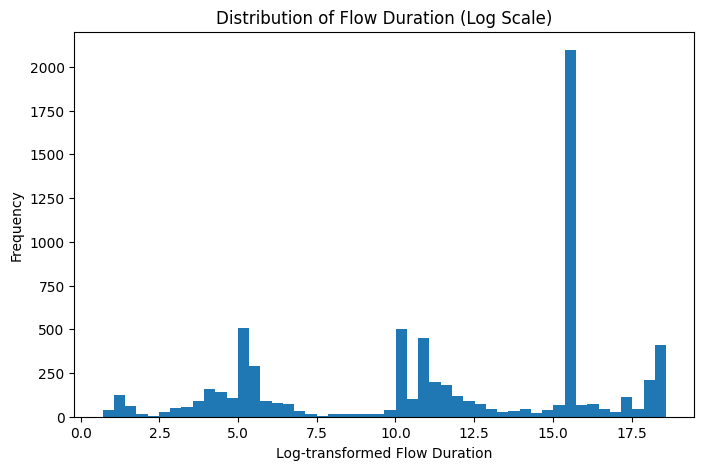

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Flow Duration']), bins=50)
plt.xlabel('Log-transformed Flow Duration')
plt.ylabel('Frequency')
plt.title('Distribution of Flow Duration (Log Scale)')
plt.show()


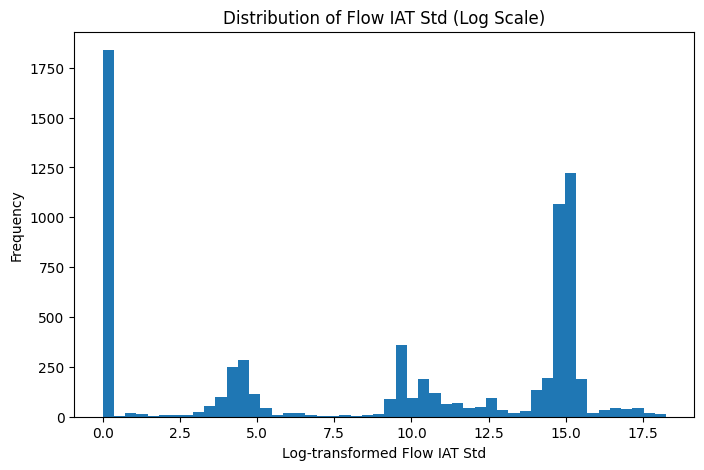

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Flow IAT Std']), bins=50)
plt.xlabel('Log-transformed Flow IAT Std')
plt.ylabel('Frequency')
plt.title('Distribution of Flow IAT Std (Log Scale)')
plt.show()

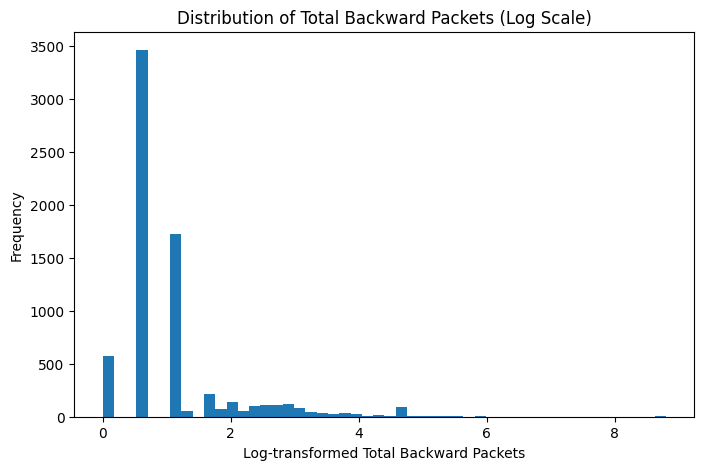

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(np.log1p(df['Total Backward Packets']), bins=50)
plt.xlabel('Log-transformed Total Backward Packets')
plt.ylabel('Frequency')
plt.title('Distribution of Total Backward Packets (Log Scale)')
plt.show()


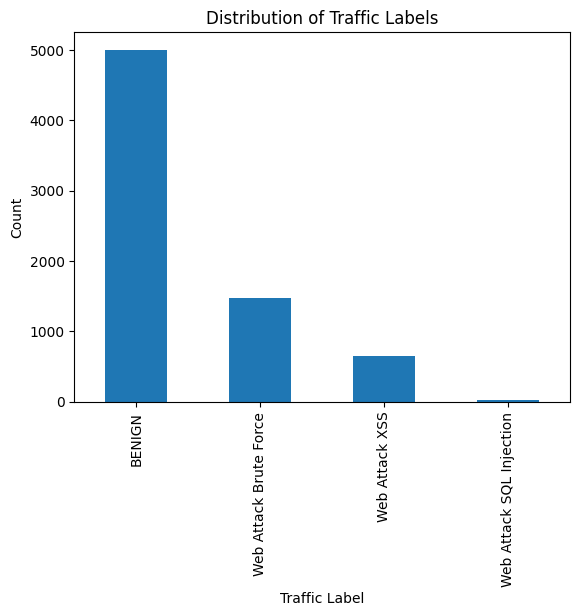

In [ ]:
df['Label'].value_counts().plot(kind='bar')
plt.xlabel('Traffic Label')
plt.ylabel('Count')
plt.title('Distribution of Traffic Labels')
plt.show()

---

<h3>Multivariate Non-Graphical EDA</h3>

---


In [ ]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

#This is to exmaine linear relatioships between numerical network traffic features between numerical network traffic features, showing how closely correlated they are.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.000000,-0.138955,-0.029155,-0.020035,-0.045775,-0.013512,-0.065293,-0.125711,-0.060522,-0.050235,...,-0.019366,-0.114324,-0.040453,-0.045904,-0.055604,-0.029576,-0.082814,-0.022692,-0.083334,-0.080473
Flow Duration,-0.138955,1.000000,0.167995,0.135231,0.204402,0.108384,0.344600,-0.139353,0.156900,0.337441,...,0.135200,-0.107447,0.179849,0.371462,0.394506,0.089185,0.618595,0.168081,0.622208,0.597635
Total Fwd Packets,-0.029155,0.167995,1.000000,0.986146,0.521715,0.976992,0.117946,-0.040611,0.068863,0.090997,...,0.987911,-0.016476,0.036675,0.080829,0.066290,0.011104,0.017449,0.015138,0.018506,0.015453
Total Backward Packets,-0.020035,0.135231,0.986146,1.000000,0.392411,0.997521,0.094055,-0.025458,0.029587,0.057212,...,0.994761,-0.028110,0.029112,0.065548,0.052565,0.010071,0.016147,0.013552,0.016943,0.014532
Total Length of Fwd Packets,-0.045775,0.204402,0.521715,0.392411,1.000000,0.353295,0.454098,-0.065955,0.506267,0.439071,...,0.426201,0.034859,0.058434,0.070713,0.082833,0.042547,0.012883,0.007804,0.013367,0.011515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,-0.029576,0.089185,0.011104,0.010071,0.042547,0.006227,0.096754,-0.023349,0.080865,0.104477,...,0.007062,-0.021068,0.936513,0.007826,0.553774,1.000000,0.156399,0.049869,0.159833,0.152934
Idle Mean,-0.082814,0.618595,0.017449,0.016147,0.012883,0.006954,0.139443,0.014716,0.083246,0.131564,...,0.014273,-0.124011,0.192628,0.140171,0.184492,0.156399,1.000000,0.145429,0.995789,0.995522
Idle Std,-0.022692,0.168081,0.015138,0.013552,0.007804,0.007966,0.040539,-0.024802,0.016496,0.037292,...,0.010490,-0.047844,0.103076,0.131339,0.105828,0.049869,0.145429,1.000000,0.232184,0.056433
Idle Max,-0.083334,0.622208,0.018506,0.016943,0.013367,0.007438,0.140459,0.012415,0.083404,0.132603,...,0.014866,-0.126515,0.201197,0.150354,0.192543,0.159833,0.995789,0.232184,1.000000,0.983614


In [ ]:
df.groupby('Label').mean(numeric_only=True)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,8246.377325,1.347684e+07,8.672266,9.916017,550.128974,11810.996401,184.817636,23.471306,50.587424,51.190264,...,5.956009,25.671666,77048.315529,50004.068764,178837.204359,52710.464507,3.982731e+06,134169.714829,4.078248e+06,3.827513e+06
Web Attack Brute Force,80.000000,6.669941e+06,12.657823,6.183673,2164.648980,3572.448299,55.877551,0.000000,17.293914,24.161707,...,4.973469,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
Web Attack SQL Injection,80.000000,2.870398e+06,3.047619,2.666667,316.000000,1286.285714,316.000000,0.000000,71.059524,149.509177,...,0.571429,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00
Web Attack XSS,80.000000,6.715357e+06,7.903374,3.573620,1197.619632,4519.015337,20.197853,0.000000,7.595968,8.693407,...,2.486196,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00


In [ ]:
df.groupby('Label').agg(['mean', 'std'])


Destination Port               Flow Duration  \
                                     mean           std          mean   
Label                                                                   
BENIGN                        8246.377325  18614.705825  1.347684e+07   
Web Attack Brute Force          80.000000      0.000000  6.669941e+06   
Web Attack SQL Injection        80.000000      0.000000  2.870398e+06   
Web Attack XSS                  80.000000      0.000000  6.715357e+06   

                                       Total Fwd Packets              \
                                   std              mean         std   
Label                                                                  
BENIGN                    3.319976e+07          8.672266  104.497583   
Web Attack Brute Force    6.411120e+06         12.657823   42.897482   
Web Attack SQL Injection  2.547204e+06          3.047619    1.802115   
Web Attack XSS            9.592863e+06          7.903374   30.779702   

                         Total Backward Packets              \
                                           mean         std   
Label                                                         
BENIGN                                 9.916017  158.234537   
Web Attack Brute Force                 6.183673   22.061249   
Web Attack SQL Injection               2.666667    1.527525   
Web Attack XSS                         3.573620   15.985279   

                         Total Length of Fwd Packets               ...  \
                                                mean          std  ...   
Label                                                              ...   
BENIGN                                    550.128974  3523.405762  ...   
Web Attack Brute Force                   2164.648980  9408.213330  ...   
Web Attack SQL Injection                  316.000000   283.478394  ...   
Web Attack XSS                           1197.619632  7459.492105  ...   

                            Active Min                    Idle Mean  \
                                  mean            std          mean   
Label                                                                 
BENIGN                    52710.464507  507518.852024  3.982731e+06   
Web Attack Brute Force        0.000000       0.000000  0.000000e+00   
Web Attack SQL Injection      0.000000       0.000000  0.000000e+00   
Web Attack XSS                0.000000       0.000000  0.000000e+00   

                                             Idle Std                \
                                   std           mean           std   
Label                                                                 
BENIGN                    1.365645e+07  134169.714829  1.665101e+06   
Web Attack Brute Force    0.000000e+00       0.000000  0.000000e+00   
Web Attack SQL Injection  0.000000e+00       0.000000  0.000000e+00   
Web Attack XSS            0.000000e+00       0.000000  0.000000e+00   

                              Idle Max                    Idle Min  \
                                  mean           std          mean   
Label                                                                
BENIGN                    4.078248e+06  1.388808e+07  3.827513e+06   
Web Attack Brute Force    0.000000e+00  0.000000e+00  0.000000e+00   
Web Attack SQL Injection  0.000000e+00  0.000000e+00  0.000000e+00   
Web Attack XSS            0.000000e+00  0.000000e+00  0.000000e+00   

                                        
                                   std  
Label                                   
BENIGN                    1.352578e+07  
Web Attack Brute Force    0.000000e+00  
Web Attack SQL Injection  0.000000e+00  
Web Attack XSS            0.000000e+00  

[4 rows x 136 columns]

In [ ]:
grouped = df.groupby('Label').mean() / df.groupby('Label').std()
grouped


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Label,,,,,,,,,,,,,,,,,,,,,
BENIGN,0.443003,0.405932,0.082990,0.062667,0.156136,0.041869,0.335288,0.620581,0.495712,0.336857,...,0.058421,4.04346,0.141958,0.160198,0.194342,0.103859,0.291637,0.080578,0.293651,0.282979
Web Attack Brute Force,inf,1.040371,0.295071,0.280296,0.230081,0.230247,0.332481,NaN,0.322390,0.332972,...,0.229866,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Web Attack SQL Injection,inf,1.126882,1.691134,1.745743,1.114723,0.871582,1.114723,NaN,1.108156,1.116965,...,1.126872,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Web Attack XSS,inf,0.700037,0.256772,0.223557,0.160550,0.161040,0.193685,NaN,0.189634,0.194120,...,0.161090,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
corr_matrix[corr_matrix > 0.95]


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
Destination Port,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flow Duration,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Fwd Packets,NaN,NaN,1.000000,0.986146,NaN,0.976992,NaN,NaN,NaN,NaN,...,0.987911,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Backward Packets,NaN,NaN,0.986146,1.000000,NaN,0.997521,NaN,NaN,NaN,NaN,...,0.994761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Length of Fwd Packets,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Active Min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
Idle Mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,0.995789,0.995522
Idle Std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
Idle Max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.995789,NaN,1.000000,0.983614


---

<h3>Multivariate Graphical EDA</h3>

---


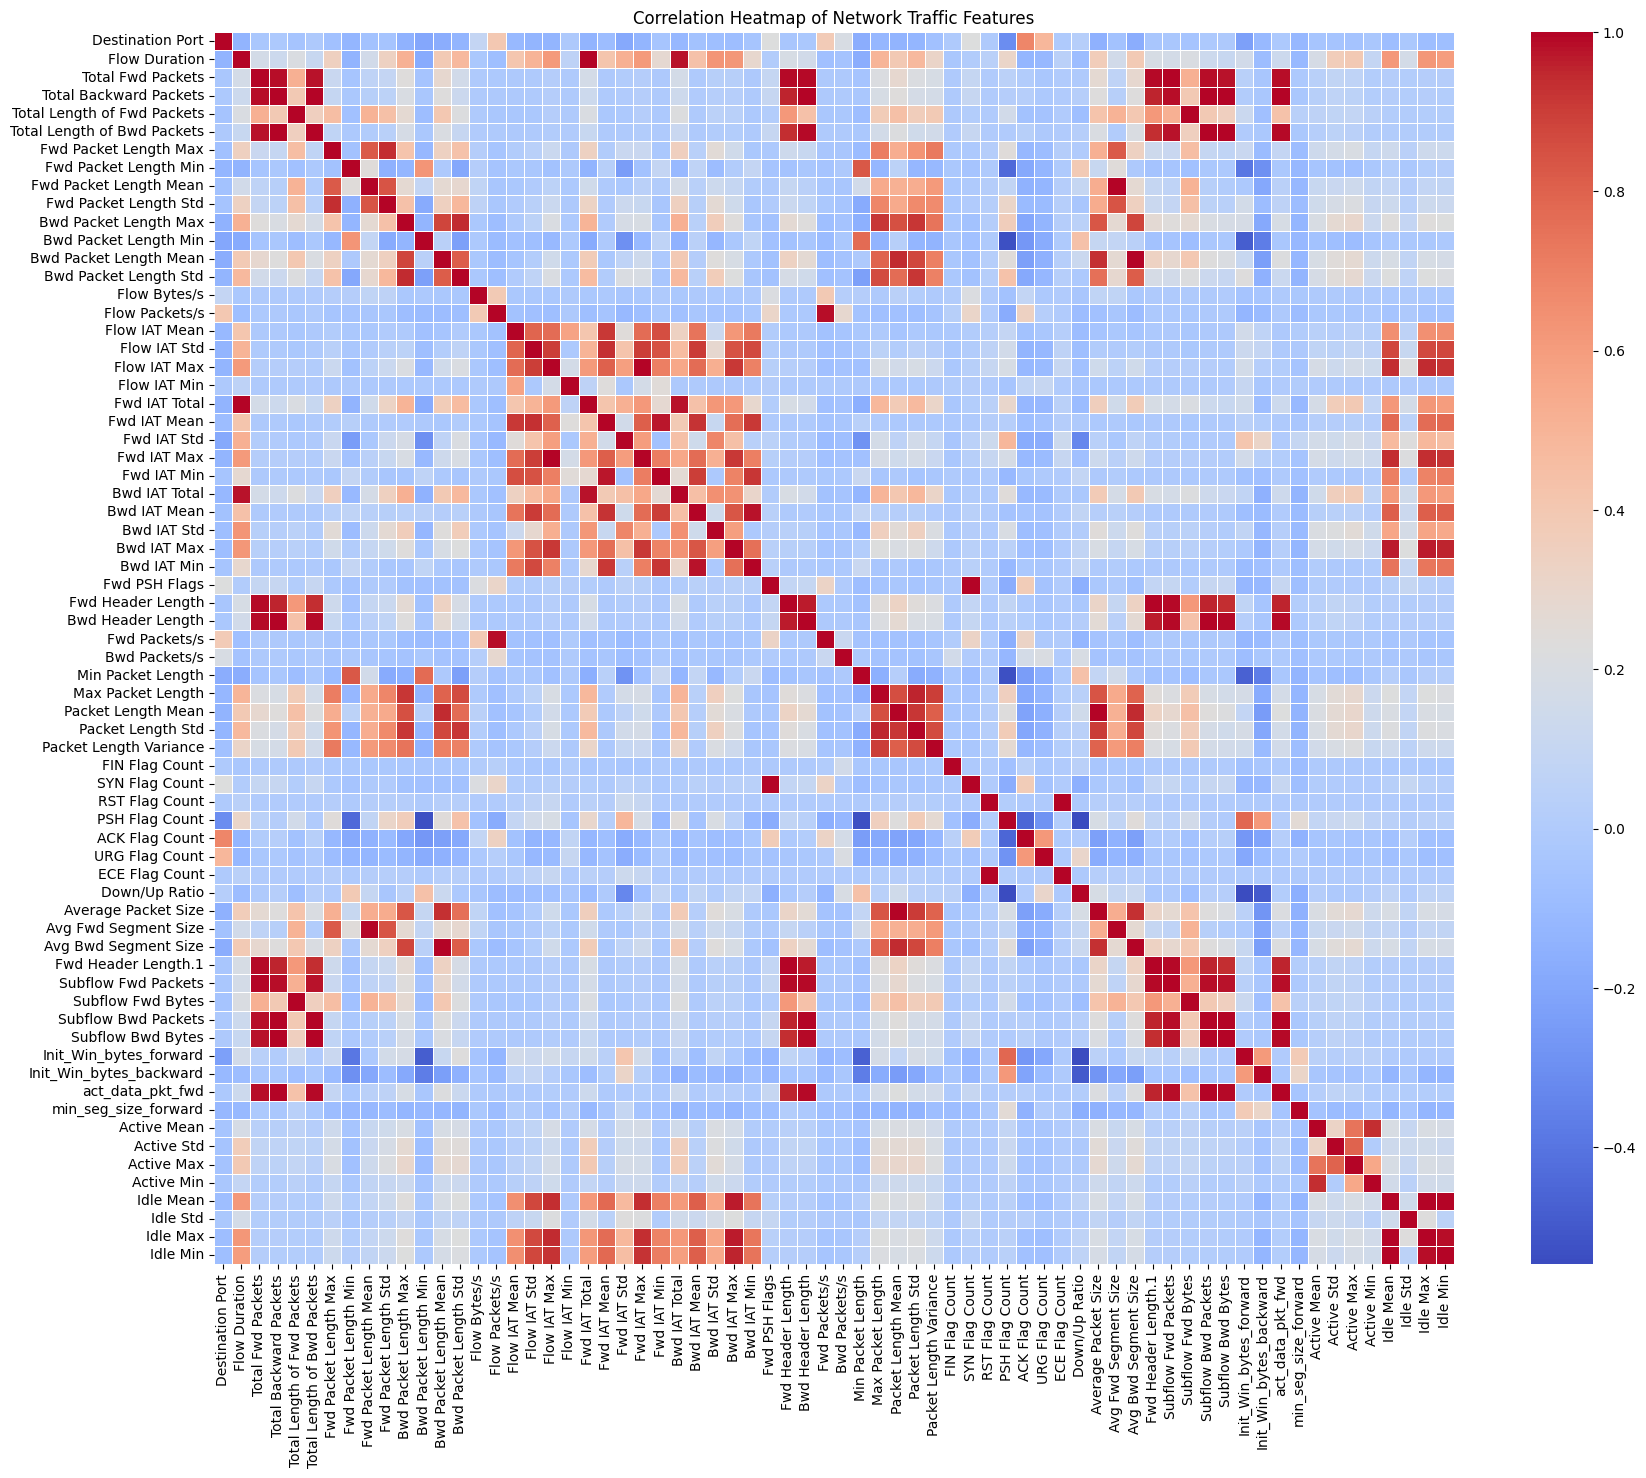

In [ ]:
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Network Traffic Features')
plt.show()

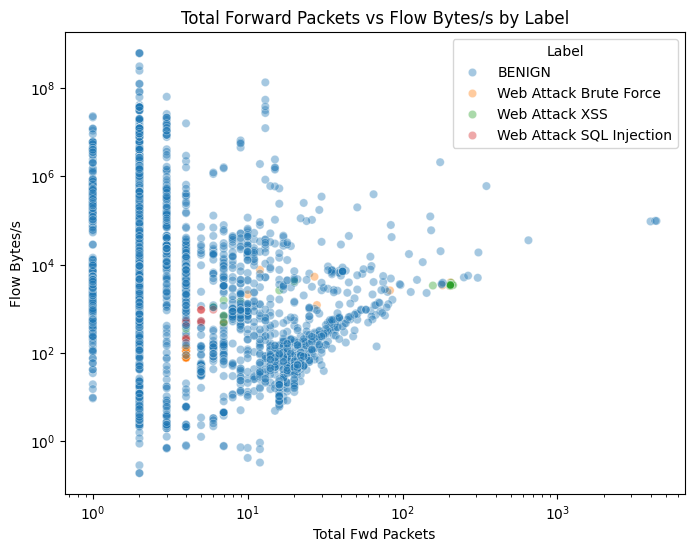

In [ ]:
#Scatter plot to examine relationship between session duration and packet volume
#Each point represents a single network flow

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x='Total Fwd Packets', #length of network sesson
    y='Flow Bytes/s',      #number of packets sent in forward direction
    hue='Label',
    alpha=0.4
)
plt.xscale('log')
plt.yscale('log')
plt.title('Total Forward Packets vs Flow Bytes/s by Label')
plt.show()


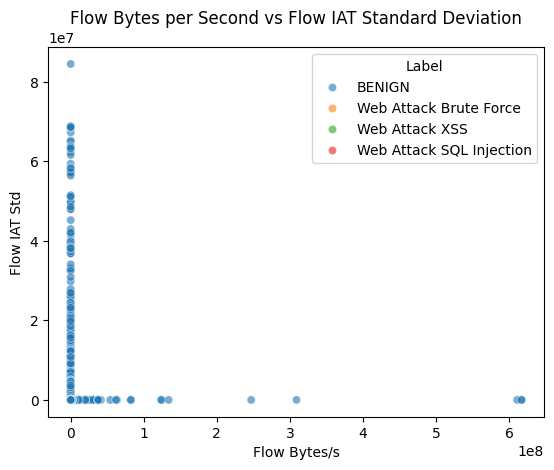

In [ ]:
#scatterplot combining traffic intensity packet timing and packet timing variability
#good to distinguish automated traffic afrom human driven traffic

sns.scatterplot(
    data=df,
    x='Flow Bytes/s',      #traffic rate in bytes per sec
    y='Flow IAT Std',      # variability in packet inter-arrival times
    hue='Label',
    alpha=0.6
)
plt.title('Flow Bytes per Second vs Flow IAT Standard Deviation')
plt.show()



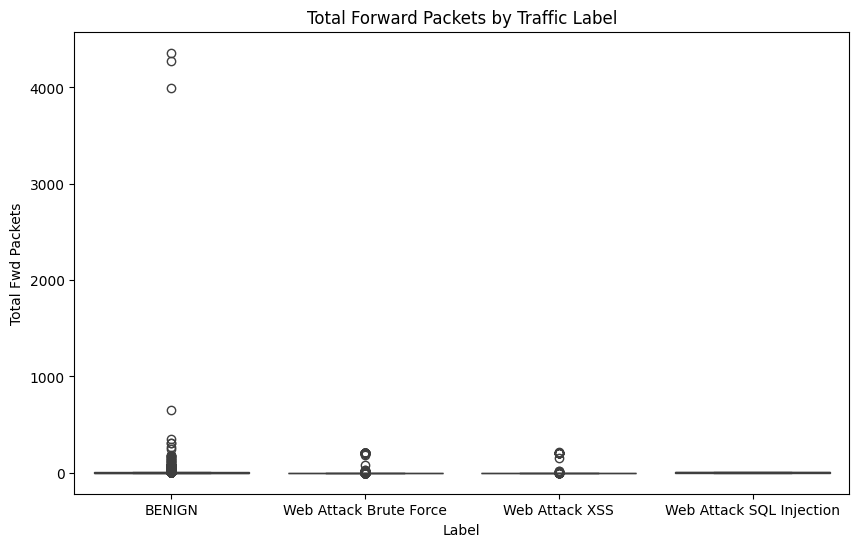

In [ ]:
#boxplot to compare packet count distributions across traffic classes
#highlights differences in median, spread, and extreme values
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Label',               #traffic class
    y='Total Fwd Packets'    #forward packet count
)

plt.title('Total Forward Packets by Traffic Label')
plt.show()


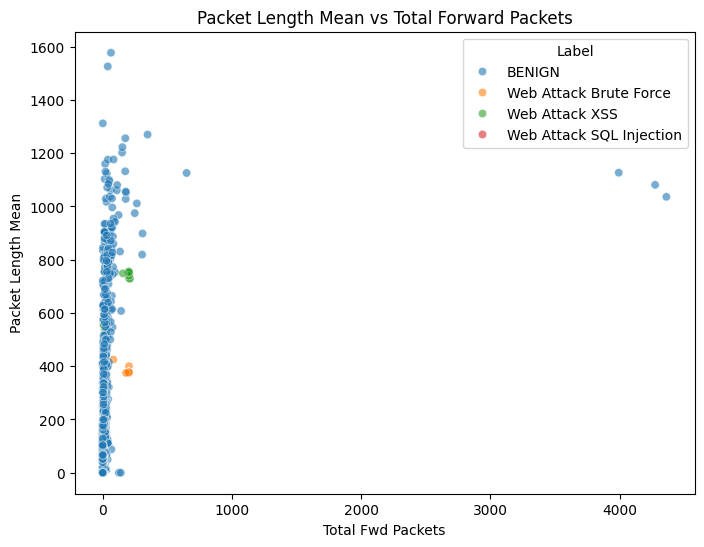

In [ ]:
# Scatter plot to examine how average packet size relates to packet volume
# Helps identify traffic with many small packets vs fewer large packets
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Total Fwd Packets',       # Number of forward packets sent
    y='Packet Length Mean',      # Average size of packets
    hue='Label',                 # Differentiate benign vs attack traffic
    alpha=0.6
)

plt.title('Packet Length Mean vs Total Forward Packets')
plt.show()


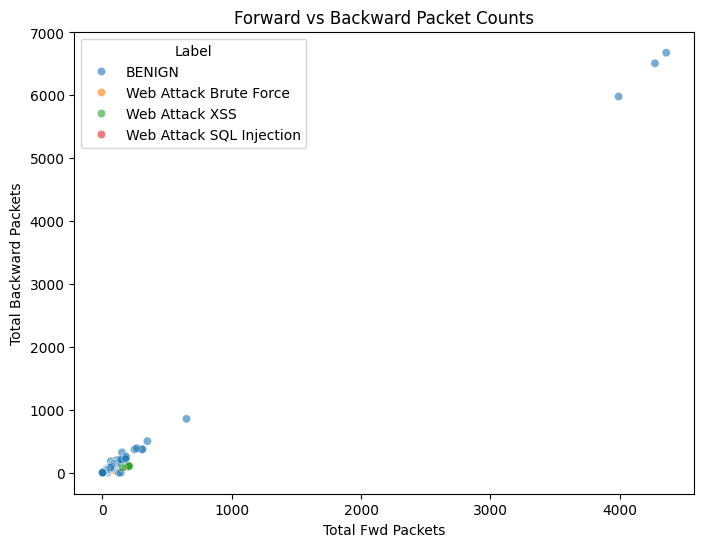

In [ ]:
# Scatter plot to compare forward and backward packet counts
# Reveals symmetry or imbalance in communication patterns
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Total Fwd Packets',
    y='Total Backward Packets',
    hue='Label',
    alpha=0.6
)

plt.title('Forward vs Backward Packet Counts')
plt.show()


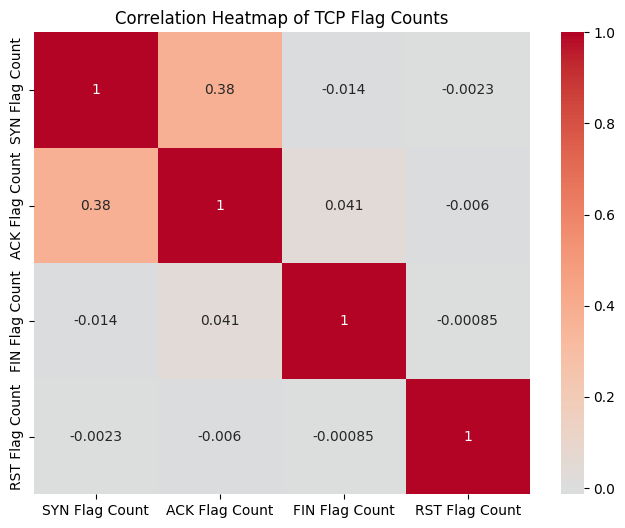

In [ ]:
# Select TCP flag-related features
flag_features = [
    'SYN Flag Count',
    'ACK Flag Count',
    'FIN Flag Count',
    'RST Flag Count'
]

# Compute correlation between TCP flag features
flag_corr = df[flag_features].corr()

# Visualise correlations to understand flag behaviour relationships
plt.figure(figsize=(8, 6))
sns.heatmap(flag_corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of TCP Flag Counts')
plt.show()



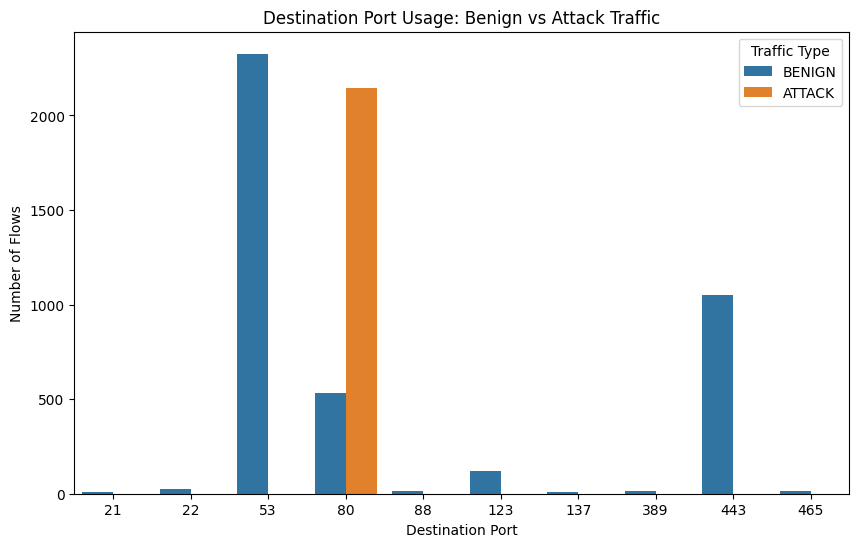

In [ ]:
# check which ports are most likely used, and which ports have the most number of attacks coming from it.
# Create a binary label for clearer comparison
# 0 = BENIGN traffic, 1 = ATTACK traffic
df['Binary_Label'] = df['Label'].apply(
    lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTACK'
)


#identify the top 10 most frequently used destination ports
top_ports = df['Destination Port'].value_counts().head(10).index

#filter the dataset to only include top destination ports
df_top_ports = df[df['Destination Port'].isin(top_ports)]

#create the count plot to compare destination port usage
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_top_ports,
    x='Destination Port',     #destination service port
    hue='Binary_Label'        #BENIGN vs ATTACK comparison
)

plt.title('Destination Port Usage: Benign vs Attack Traffic')
plt.ylabel('Number of Flows')
plt.xlabel('Destination Port')
plt.legend(title='Traffic Type')
plt.show()





---

<h1 align="left"><font color='#FFB703'>Feature Engineering</font></h1>

---



In [ ]:
df = pd.read_csv('web_attacks_balanced.csv')

In [ ]:
df['byte_direction_imbalance'] = (
    abs(df['Total Length of Fwd Packets'] - df['Total Length of Bwd Packets']) /
    (df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets'] + 1)
)

#Bwd Packets: Bytes sent from server → client
#value close to 1: Extremely one-sided (likely attack)

In [ ]:
df['packet_variability'] = df['Packet Length Std'] / (df['Packet Length Mean'] + 1)
#Measures consistency of packet sizes
#Low variability: repeated identical packets → automated attacks
#High variability: irregular payloads → injection attacks

In [ ]:
df['flow_completeness'] = df['Total Backward Packets'] / (df['Total Fwd Packets'] + 1)
#Measures how many server responses occur per client request
#Low value: many failed or blocked requests → attack behaviour
#High value: successful and complete sessions (benign)

In [ ]:
df["small_payload_ratio"] = df["Min Packet Length"] / (df["Max Packet Length"] + 1)
#Captures presence of very small packets
#High ratio: uniform packet sizes (normal traffic)
#Low ratio: probing or injection packets (XSS / SQLi)


In [ ]:
df["fwd_packet_ratio"] = df["Total Fwd Packets"] / (
    df["Total Fwd Packets"] + df["Total Backward Packets"] + 1
)
#Measures dominance of client-to-server traffic
#High ratio: request-heavy traffic → brute force / probing
#Balanced ratio: normal bidirectional communication

In [ ]:
df["auth_payload_ratio"] = ( df["Total Length of Fwd Packets"] /
    (df["Total Length of Fwd Packets"] + df["Total Length of Bwd Packets"] + 1))
#Measures proportion of data sent from client → server
#Value close to 1: Client sends much more data than server - SQLi / XSS

In [ ]:
df["header_payload_ratio"] = ((df["Fwd Header Length"] + df["Bwd Header Length"])
/
(df["Total Length of Fwd Packets"] + df["Total Length of Bwd Packets"] + 1))
#Measures how much traffic consists of protocol headers
#High value: Many small packets with large headers - brute force

In [ ]:
df["handshake_intensity"] = ((df["SYN Flag Count"] + df["ACK Flag Count"] + df["RST Flag Count"])
/
(df["Total Fwd Packets"] + df["Total Backward Packets"] + 1))
#Measures frequency of TCP control flags per packet
#High value: Repeated connection attempts or resets - brute force

<h2 align="left"><font color='#FFB703'>Identify important Features</font></h2>


---



In [ ]:
df["Binary_Label"] = df["Label"].isin([
    "Web Attack Brute Force",
    "Web Attack XSS",
    "Web Attack SQL Injection"]).astype(int)

In [ ]:
df[["Label", "Binary_Label"]].value_counts()

,,count
Label,Binary_Label,
BENIGN,0,5001
Web Attack Brute Force,1,1470
Web Attack XSS,1,652
Web Attack SQL Injection,1,21


In [ ]:
corr_matrix = df.corr(numeric_only=True)

In [ ]:
correlations = corr_matrix['Binary_Label'].drop('Binary_Label').abs().sort_values(ascending=False)

In [ ]:
print(correlations.head(20))

header_payload_ratio        0.863790
Init_Win_bytes_backward     0.715638
Init_Win_bytes_forward      0.653739
PSH Flag Count              0.645634
byte_direction_imbalance    0.578776
auth_payload_ratio          0.531808
Down/Up Ratio               0.510797
small_payload_ratio         0.485587
min_seg_size_forward        0.479204
fwd_packet_ratio            0.473770
flow_completeness           0.431760
Bwd Packet Length Min       0.387517
Min Packet Length           0.386296
packet_variability          0.374794
Fwd Packet Length Min       0.321839
Fwd IAT Std                 0.299766
Average Packet Size         0.271455
Packet Length Mean          0.238380
Destination Port            0.233650
ACK Flag Count              0.228243
Name: Binary_Label, dtype: float64


<h2 align="left"><font color='#FFB703'>Dropping Reclutant Features</font></h2>


---

In [ ]:
#from the left-most spike, Thousands of flows share nearly identical initial window sizes, These identical values come from
#Default TCP window sizes set by the OS and Not from attacker behaviour.
#This model learns windows size = attack but in reality it is just a common os default and result in false positive

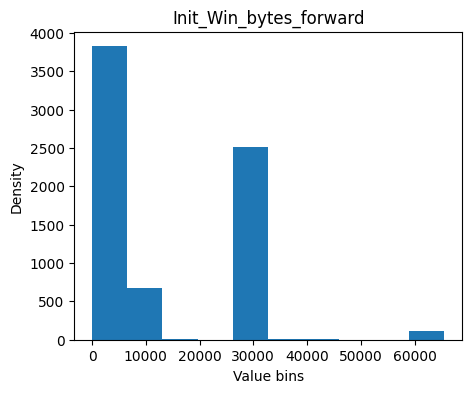

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(df["Init_Win_bytes_forward"], bins=10)
plt.title("Init_Win_bytes_forward")
plt.xlabel("Value bins")
plt.ylabel("Density")
plt.show()

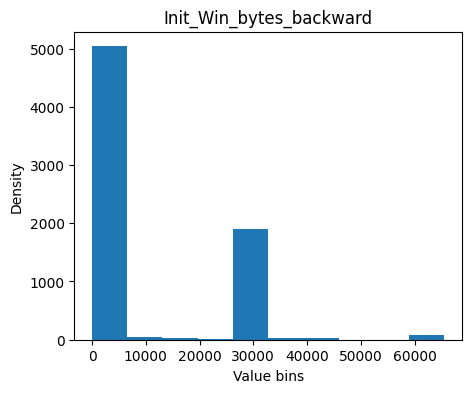

In [ ]:
plt.figure(figsize=(5,4))
plt.hist(df["Init_Win_bytes_backward"], bins=10)
plt.title("Init_Win_bytes_backward")
plt.xlabel("Value bins")
plt.ylabel("Density")
plt.show()

In [ ]:
similar_features = df[[
    "Min Packet Length",
    "Fwd Packet Length Min",
    "Bwd Packet Length Min",
]]
similar_features.corr()

,Min Packet Length,Fwd Packet Length Min,Bwd Packet Length Min
Min Packet Length,1.000000,0.826254,0.773628
Fwd Packet Length Min,0.826254,1.000000,0.629954
Bwd Packet Length Min,0.773628,0.629954,1.000000


In [ ]:
df.shape

(7144, 78)

In [ ]:
df = df.drop(columns=['Init_Win_bytes_backward', 'Init_Win_bytes_forward',   "Fwd Packet Length Min",
    "Bwd Packet Length Min",])

In [ ]:
df.shape

(7144, 74)

In [ ]:
#recompute everything
corr_matrix = df.corr(numeric_only=True)
correlations = corr_matrix['Binary_Label'].drop('Binary_Label').abs().sort_values(ascending=False)

In [ ]:
print(correlations.head(29))

header_payload_ratio        0.863790
PSH Flag Count              0.645634
byte_direction_imbalance    0.578776
auth_payload_ratio          0.531808
Down/Up Ratio               0.510797
small_payload_ratio         0.485587
min_seg_size_forward        0.479204
fwd_packet_ratio            0.473770
flow_completeness           0.431760
Min Packet Length           0.386296
packet_variability          0.374794
Fwd IAT Std                 0.299766
Average Packet Size         0.271455
Packet Length Mean          0.238380
Destination Port            0.233650
ACK Flag Count              0.228243
handshake_intensity         0.213830
Packet Length Std           0.207692
Avg Bwd Segment Size        0.207371
Bwd Packet Length Mean      0.207371
Max Packet Length           0.192166
Bwd Packet Length Max       0.191179
Fwd Packet Length Mean      0.179423
Avg Fwd Segment Size        0.179423
Bwd IAT Total               0.170640
Bwd Packet Length Std       0.167567
Idle Max                    0.158807
I

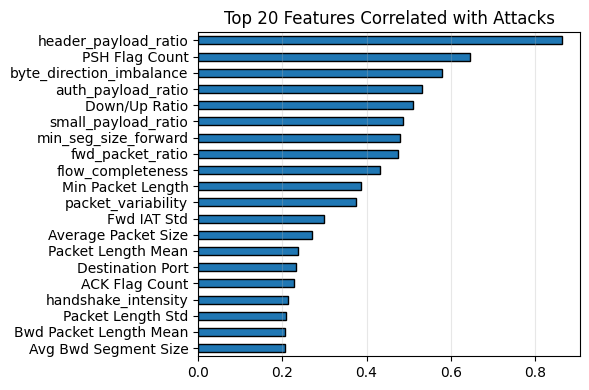

In [ ]:
top_corr = correlations.head(20).sort_values()

plt.figure(figsize=(6, 4))
top_corr.plot(kind='barh', edgecolor='black')
plt.title("Top 20 Features Correlated with Attacks")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()




---

<h1 align="left"><font color='#FFB703'>BENIGN vs ATTACK
model.</font></h1>

---



In [ ]:
selected_features = df[[
    "header_payload_ratio",
    "PSH Flag Count",
    "byte_direction_imbalance",
    "auth_payload_ratio",
    "Down/Up Ratio",
    "small_payload_ratio",
    "min_seg_size_forward",
    "fwd_packet_ratio",
    "flow_completeness",
    "Min Packet Length",
    "packet_variability",
    "Fwd IAT Std",
    "Average Packet Size",
    "Packet Length Mean",
    "Destination Port",
    "ACK Flag Count",
    "handshake_intensity",
    "Packet Length Std",
    "Avg Bwd Segment Size",
    "Bwd Packet Length Mean"
]]



In [ ]:
x= selected_features.loc[df.index]
y = df["Binary_Label"].values
print(x.shape, y.shape)

(7144, 20) (7144,)


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)
#stratify=y ensures that both the training and testing sets preserve the original class distribution
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape) #the model is trained on 5000 samples and evaluated on 2,144 unseen samples

(5000, 20) (5000,)
(2144, 20) (2144,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression(class_weight = "balanced")
logreg.fit(x_train, y_train)


LogisticRegression(class_weight='balanced')

In [ ]:
y_pred= logreg.predict(x_test)
y_pred

array([1, 1, 0, ..., 1, 0, 1])

<h2 align="left"><font color='#FFB703'>BENIGN vs ATTACK evaluation</font></h2>

---

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[1455   46]
 [   2  641]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1501
           1       0.93      1.00      0.96       643

    accuracy                           0.98      2144
   macro avg       0.97      0.98      0.97      2144
weighted avg       0.98      0.98      0.98      2144





---


<h1 align="left"><font color='#FFB703'>Multiclass Classification</font></h1>

---




In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['attack_type'] = le.fit_transform(df['Label'])

In [ ]:
x1 = selected_features
y1 = df["attack_type"]
y1.value_counts()

,count
attack_type,
0,5001
1,1470
3,652
2,21


In [ ]:
x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, test_size=0.3, random_state=42,stratify=y)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(5000, 20) (5000,)
(2144, 20) (2144,)


In [ ]:
scaler = StandardScaler()
x_train1 = scaler.fit_transform(x_train1)
x_test1 = scaler.transform(x_test1)

In [ ]:
logreg1 = LogisticRegression(class_weight='balanced',max_iter=1000)
logreg1.fit(x_train1, y_train1)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred1 = logreg1.predict(x_test1)
y_pred1

array([3, 3, 0, ..., 2, 0, 1])

In [ ]:
print(confusion_matrix(y_test1, y_pred1))
print(classification_report(y_test1, y_pred1, target_names=le.classes_, labels=le.transform(le.classes_)))

[[1434    7   34   26]
 [   0  232   41  180]
 [   0    0    6    0]
 [   0   41    4  139]]
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.96      0.98      1501
  Web Attack Brute Force       0.83      0.51      0.63       453
Web Attack SQL Injection       0.07      1.00      0.13         6
          Web Attack XSS       0.40      0.76      0.53       184

                accuracy                           0.84      2144
               macro avg       0.58      0.81      0.57      2144
            weighted avg       0.91      0.84      0.86      2144

